In [35]:
import torch
from torch import nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [36]:
data=torch.arange(0,1,0.02).unsqueeze(1)

In [37]:
data
p=90*data+300

In [38]:
x_train=data[:int(0.8*len(data))].to('mps')
y_train=p[:int(0.8*len(data))].to('mps')

In [39]:
x_test=data[int(0.8*len(data)):].to('mps')
y_test=p[int(0.8*len(data)):].to('mps')

In [40]:
model=nn.Sequential(
    nn.Linear(in_features=1,out_features=25),
    nn.Linear(in_features=25,out_features=1)
).to('mps')

In [41]:
model(x_test)

tensor([[-0.5851],
        [-0.5816],
        [-0.5782],
        [-0.5747],
        [-0.5713],
        [-0.5678],
        [-0.5644],
        [-0.5609],
        [-0.5575],
        [-0.5540]], device='mps:0', grad_fn=<LinearBackward0>)

In [42]:
loss_fn=nn.L1Loss()

In [43]:
optimizer=torch.optim.SGD(params=model.parameters(),lr=0.01)

In [44]:
epochs=250
l=[]
for epoch in range(epochs):

    model.train()
    y_p=model(x_train)
    loss=loss_fn(y_p,y_train)
    l.append(loss.to('cpu'))
    print(f"epoch :{epoch} loss : {loss}")
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

epoch :0 loss : 335.7558288574219
epoch :1 loss : 335.6241760253906
epoch :2 loss : 335.4927673339844
epoch :3 loss : 335.3615417480469
epoch :4 loss : 335.2303161621094
epoch :5 loss : 335.09918212890625
epoch :6 loss : 334.9679870605469
epoch :7 loss : 334.83673095703125
epoch :8 loss : 334.705322265625
epoch :9 loss : 334.5737609863281
epoch :10 loss : 334.44195556640625
epoch :11 loss : 334.309814453125
epoch :12 loss : 334.1773376464844
epoch :13 loss : 334.04443359375
epoch :14 loss : 333.9110412597656
epoch :15 loss : 333.7771911621094
epoch :16 loss : 333.6426696777344
epoch :17 loss : 333.5075378417969
epoch :18 loss : 333.3717346191406
epoch :19 loss : 333.235107421875
epoch :20 loss : 333.0977478027344
epoch :21 loss : 332.9594421386719
epoch :22 loss : 332.8202209472656
epoch :23 loss : 332.6800231933594
epoch :24 loss : 332.5387878417969
epoch :25 loss : 332.3963928222656
epoch :26 loss : 332.25286865234375
epoch :27 loss : 332.10809326171875
epoch :28 loss : 331.962005615

In [45]:
list(model.parameters())

[Parameter containing:
 tensor([[ 2.4916],
         [-0.6781],
         [-1.1049],
         [ 1.8222],
         [-1.4237],
         [ 0.3267],
         [-0.3722],
         [ 2.7351],
         [ 0.5442],
         [-0.2143],
         [-1.2904],
         [ 2.4248],
         [-1.7560],
         [ 1.1805],
         [-0.2922],
         [-0.4747],
         [ 2.1649],
         [-0.2930],
         [ 1.8654],
         [-0.4032],
         [-0.5064],
         [ 1.3489],
         [ 0.7628],
         [-0.5873],
         [ 0.3031]], device='mps:0', requires_grad=True),
 Parameter containing:
 tensor([ 5.9176,  0.6449, -3.8855,  4.9735, -1.6220,  2.3614, -1.7403,  6.2157,
          0.3367, -2.0505, -0.4864,  5.3822, -2.8961,  3.2449, -2.4296, -1.4123,
          6.0606,  1.2082,  5.4633, -0.2618, -2.8405,  1.3621, -1.3208, -1.8790,
          2.9537], device='mps:0', requires_grad=True),
 Parameter containing:
 tensor([[ 6.2936,  0.4051, -3.9504,  5.2175, -1.9665,  2.2958, -1.7564,  6.6909,
           0

In [46]:
y_test

tensor([[372.0000],
        [373.8000],
        [375.6000],
        [377.4000],
        [379.2000],
        [381.0000],
        [382.8000],
        [384.6000],
        [386.4000],
        [388.2000]], device='mps:0')

In [47]:
with torch.inference_mode():

    y_pred=model(x_test)

In [48]:
y_pred

tensor([[378.8543],
        [381.0119],
        [383.1695],
        [385.3272],
        [387.4848],
        [389.6424],
        [391.8000],
        [393.9577],
        [396.1153],
        [398.2729]], device='mps:0')

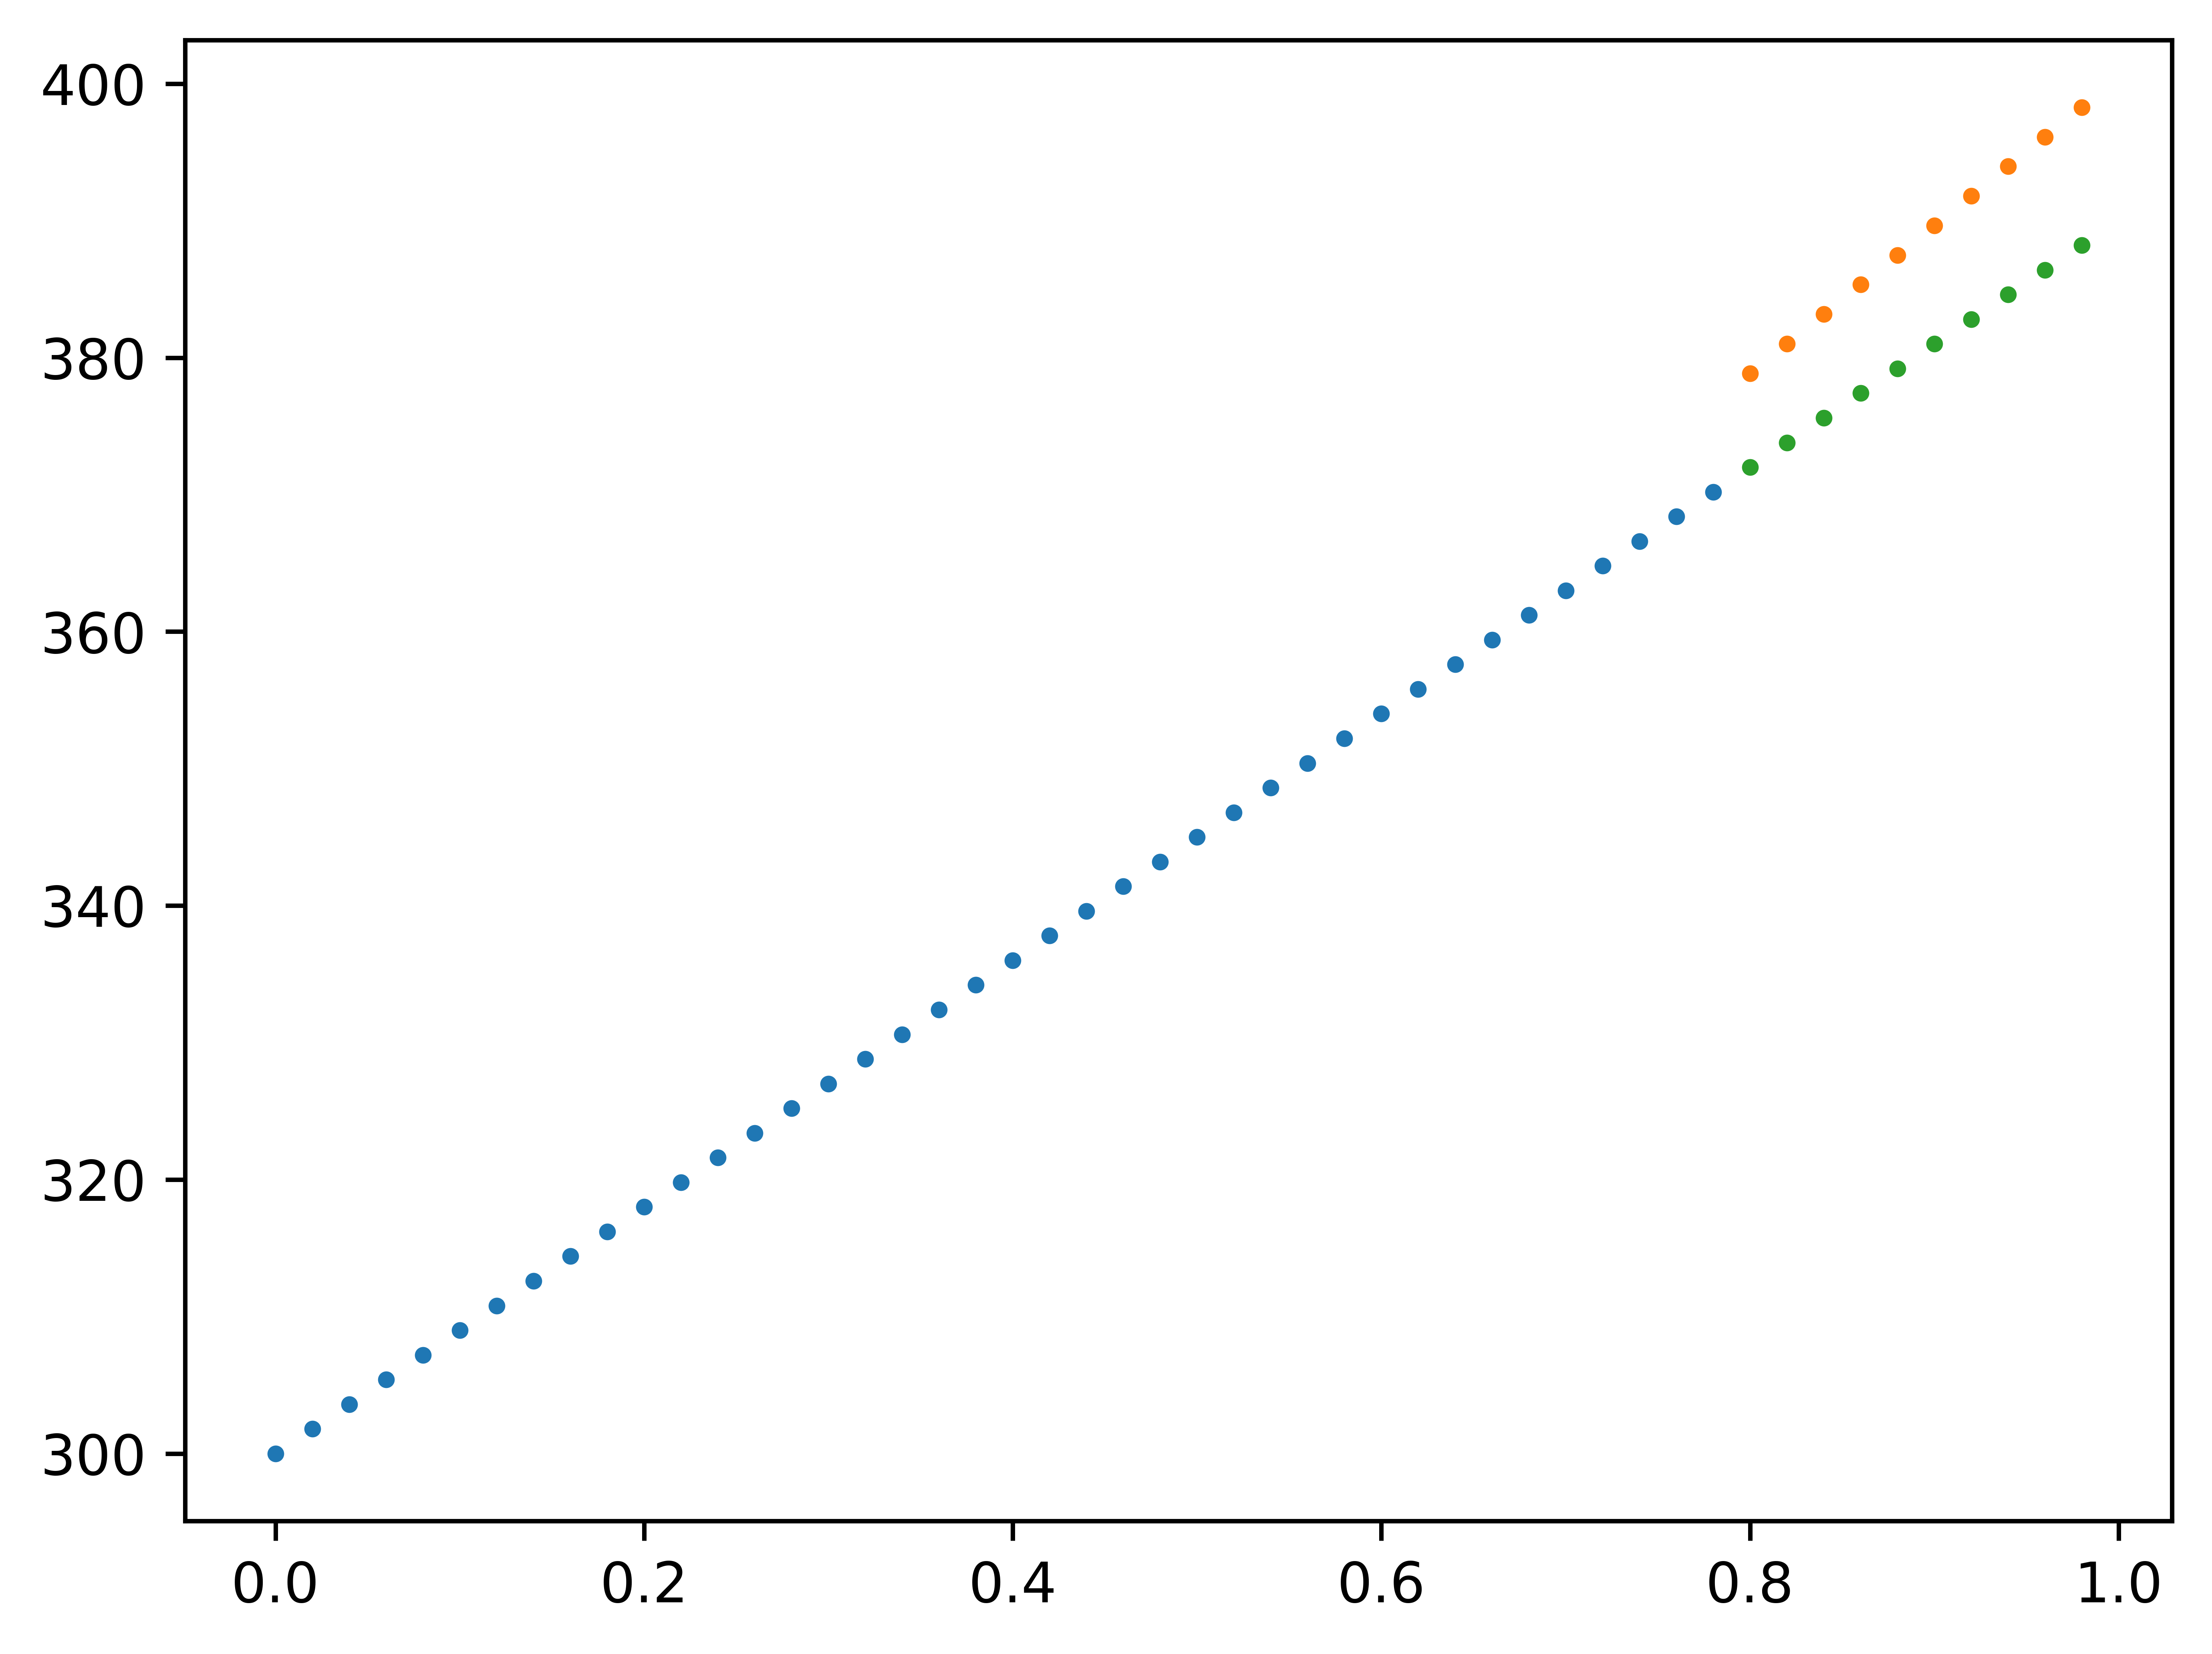

In [49]:
plt.figure(dpi=1000)
plt.scatter(x_train.to('cpu').numpy(),y_train.to('cpu').numpy(),s=4)
plt.scatter(x_test.to('cpu').numpy(),y_pred.to('cpu').numpy(),s=4)
plt.scatter(x_test.to('cpu').numpy(),y_test.to('cpu').numpy(),s=4)


In [50]:
lo=[i.detach().numpy() for i in l]

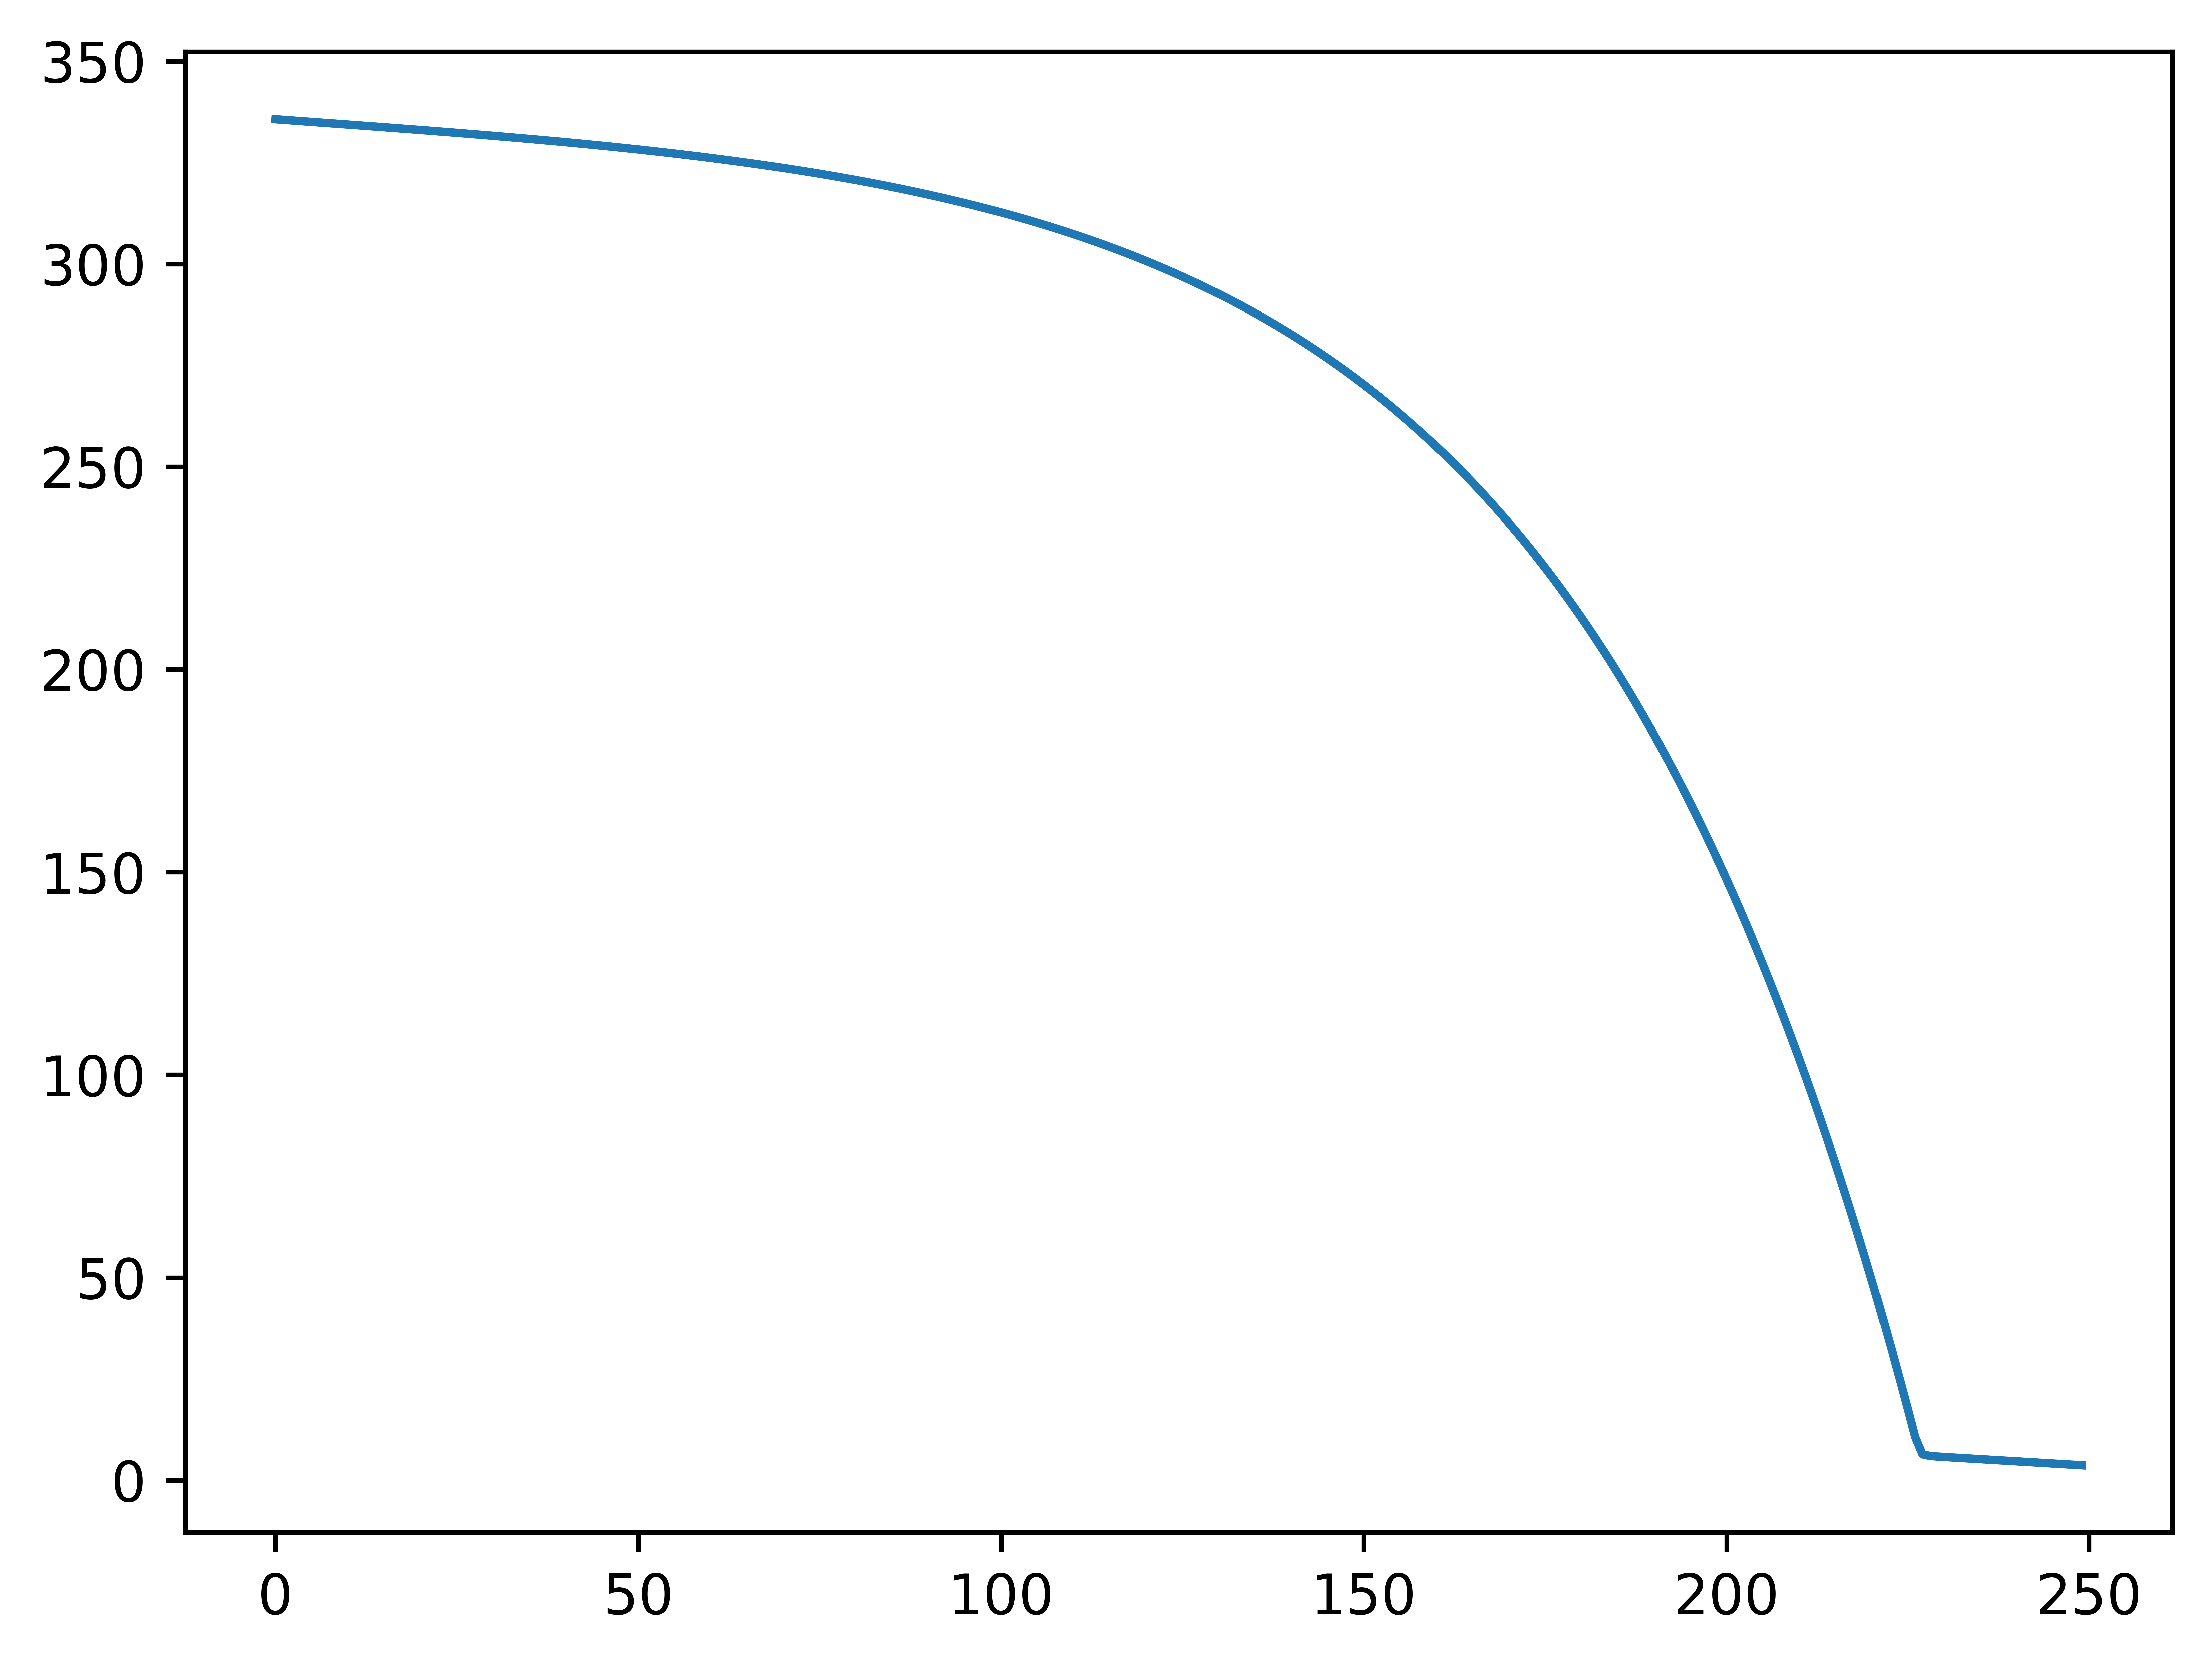

In [51]:
plt.figure(dpi=1200)
plt.plot(lo)